# MÓDULO 1: Preprocesamiento y EDA

Este notebook carga el dataset crudo de espectros Mössbauer, aplica limpieza lexicográfica y filtrado físico de velocidades, homogeneiza la longitud de los espectros por interpolación, genera visualizaciones exploratorias, codifica las clases cristaloquímicas en one-hot y produce pseudo-etiquetas topológicas mediante ajuste paralelo de modelos Lmfit.

In [1]:
import json
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns
from multiprocessing import Pool, cpu_count
from tqdm import tqdm

sys.path.append(os.path.abspath('.'))
from src.mossbauer_models import select_best_model, extract_hyperfine_vector, build_model, evaluate_model

print("=== MÓDULO 1: Preprocesamiento y EDA ===")

=== MÓDULO 1: Preprocesamiento y EDA ===


## Funciones auxiliares

In [2]:
def load_spectra(sample):
    """
    Deserializes the vectors of a spectrum from the DataFrame.
    
    Args:
        sample: row (or slice of 1 row) of the DataFrame.
    Returns:
        velocity (list[float]): velocities in mm/s.
        intensity (list[float]): relative transmission.
    """
    intensity = json.loads(sample['Intensity'].values[0])
    velocity  = json.loads(sample['Velocity (mm/s)'].values[0])
    return velocity, intensity


def filter_spectrum(sample_row):
    """
    Deserializes and filters a spectrum, removing points with |v| > 50 mm/s.
    
    Returns:
        velocity_filtered (list[float])
        intensity_filtered (list[float])
    
    Physical basis: the range ±50 mm/s corresponds to the standard
    Doppler modulation interval of the transducer in 57Fe Mössbauer spectroscopy.
    Velocities outside this range are physically impossible for this isotope.
    """
    velocity, intensity = load_spectra(sample_row.to_frame().T)
    pairs = [(v, i) for v, i in zip(velocity, intensity) if -50 <= v <= 50]
    if not pairs:
        return None, None
    v_filt, i_filt = zip(*pairs)
    return list(v_filt), list(i_filt)


def interpolate_to_length(velocity, intensity, target_len):
    """
    Interpolates a spectrum to a fixed length using cubic spline interpolation.
    The velocity axis acts as the physical independent variable.
    Handles duplicate velocity values by grouping and averaging.
    """
    df_temp = pd.DataFrame({'v': velocity, 'i': intensity})
    df_temp = df_temp.groupby('v', as_index=False).mean()
    
    v_arr = df_temp['v'].values
    i_arr = df_temp['i'].values
    
    kind = 'cubic' if len(v_arr) >= 4 else 'linear'
    v_new = np.linspace(v_arr.min(), v_arr.max(), target_len)
    
    interp_fn = interp1d(v_arr, i_arr, kind=kind, fill_value='extrapolate')
    i_new = interp_fn(v_new)
    
    return v_new.tolist(), i_new.tolist()


def fit_worker(args):
    idx, pkey, v_uni, i_uni = args
    v_arr = np.array(v_uni)
    i_arr = np.array(i_uni)
    
    best_idx, best_result = select_best_model(v_arr, i_arr)
    p_vec = extract_hyperfine_vector(best_result, best_idx)
    
    if best_result is not None:
        y_fit = 1.0 + evaluate_model(best_result.params, v_arr, best_idx)
        rmse = float(np.sqrt(np.mean((y_fit - i_arr)**2)))
    else:
        rmse = 1.0
        
    return idx, best_idx, p_vec, best_idx, rmse

## 1. Carga del dataset

In [3]:
ruta_csv = Path('Data/data.csv')
if not ruta_csv.exists():
    raise FileNotFoundError(f"No se encontró el dataset en {ruta_csv}")

df = pd.read_csv(ruta_csv)
print(f"Cargado dataset inicial. Registros: {df.shape[0]}")
df.sample(1)

Cargado dataset inicial. Registros: 7246


,pkey,Dana Class,folder,Sample Name,Owner/Source,Temperature (K),Intensity,Velocity (mm/s)
4964,11031102,Simple Oxides,Oxide,Magnetite V.1 62nm,"Nyiro-Kosa,Ilona",275.0,"[-0.199, -0.16, -0.019, -0.006, -0.017, -0.041...","[-12.186, -12.138, -12.09, -12.042, -11.994, -..."


## 1.1 Limpieza lexicográfica sobre folder

In [4]:
PURGE_LABELS = [
    'Mixed', 'Mixtures', 'Industrial Samples',
    'Biogeochemical Mineralogical By-Products',
    'H', 'OH', None, ''
]

initial_len = len(df)
df = df[~df['folder'].isin(PURGE_LABELS) & df['folder'].notna()].reset_index(drop=True)
print(f"Filas eliminadas por PURGE_LABELS: {initial_len - len(df)}")

initial_len = len(df)
df = df.drop_duplicates(subset=['pkey']).reset_index(drop=True)
print(f"Filas duplicadas eliminadas por pkey: {initial_len - len(df)}")

Filas eliminadas por PURGE_LABELS: 1957
Filas duplicadas eliminadas por pkey: 0


## 1.2 Deserialización y filtro físico de velocidades

In [5]:
initial_len = len(df)
filtered_vels = []
filtered_ints = []
valid_indices = []

print("Aplicando filtro: eliminando espectros que tengan al menos una velocidad >= 20 mm/s...")
for idx, row in df.iterrows():
    try:
        v_filt, i_filt = filter_spectrum(row)
        # Requiere que el espectro exista (no None) y que ninguna velocidad sea >= 20
        if v_filt is not None and all(abs(v) < 20 for v in v_filt):
            filtered_vels.append(v_filt)
            filtered_ints.append(i_filt)
            valid_indices.append(idx)
    except Exception:
        pass

df = df.loc[valid_indices].copy().reset_index(drop=True)
df['velocity_filtered'] = filtered_vels
df['intensity_filtered'] = filtered_ints
print(f"Filas eliminadas tras filtro de velocidad (descartando aquellas con alguna velocidad >= 20 mm/s): {initial_len - len(df)}")

Aplicando filtro: eliminando espectros que tengan al menos una velocidad >= 20 mm/s...
Filas eliminadas tras filtro de velocidad (descartando aquellas con alguna velocidad >= 20 mm/s): 260


## 1.3 Homogeneización de longitud por interpolación al máximo

In [6]:
target_len = max(len(v) for v in df['velocity_filtered'])
print(f"Longitud objetivo de interpolación: {target_len} puntos")

df['velocity_uniform'] = None
df['intensity_uniform'] = None

print("Interpolando espectros...")
for idx, row in df.iterrows():
    v_uni, i_uni = interpolate_to_length(
        row['velocity_filtered'], row['intensity_filtered'], target_len
    )
    df.at[idx, 'velocity_uniform'] = v_uni
    df.at[idx, 'intensity_uniform'] = i_uni

assert all(len(v) == target_len for v in df['velocity_uniform']), \
    "ERROR: No todos los vectores tienen la misma longitud"
assert all(len(i) == target_len for i in df['intensity_uniform']), \
    "ERROR: No todos los vectores de intensidad tienen la misma longitud"
print(f"✓ Todos los espectros tienen longitud uniforme: {target_len}")

Longitud objetivo de interpolación: 512 puntos
Interpolando espectros...
✓ Todos los espectros tienen longitud uniforme: 512


## 1.4 Análisis exploratorio visual

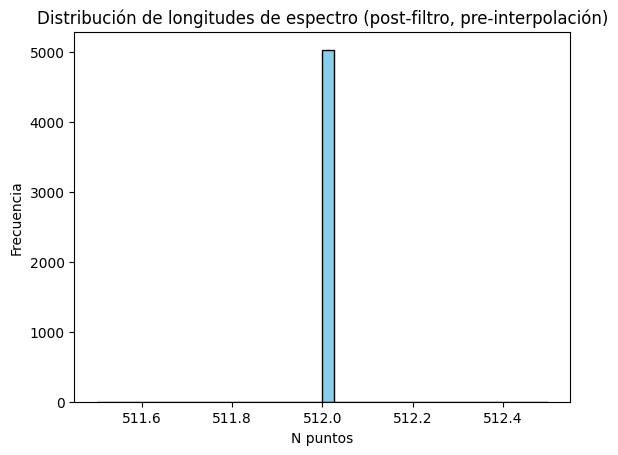

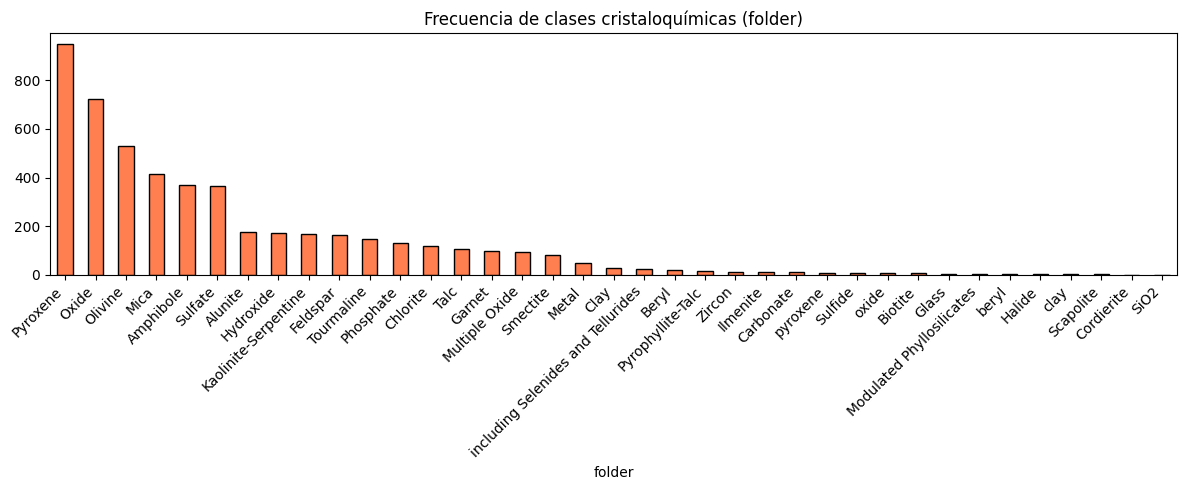

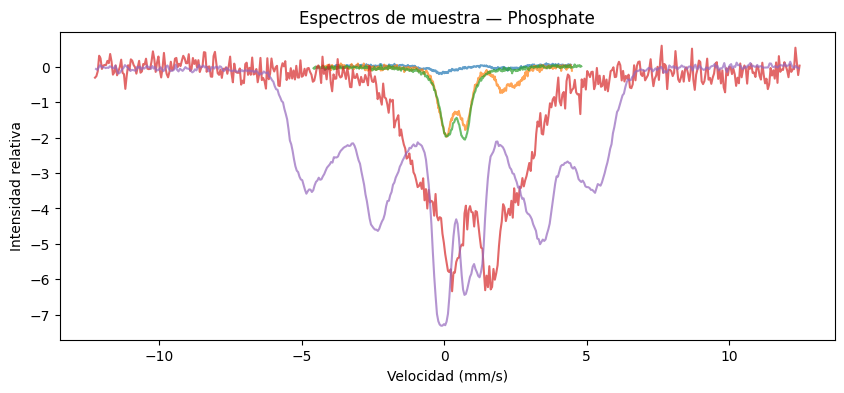

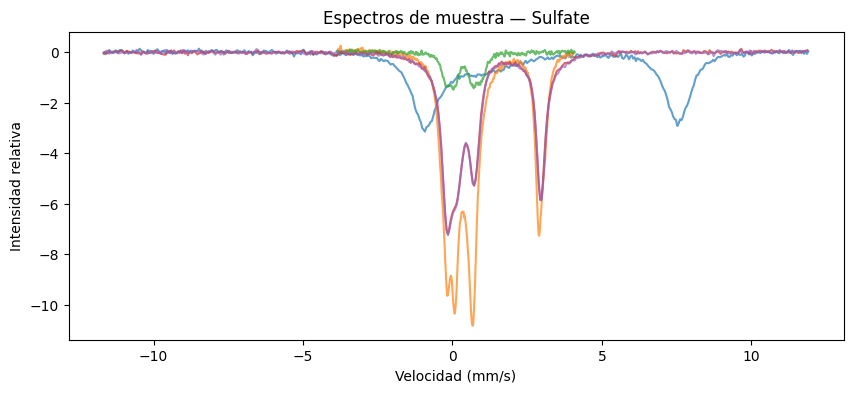

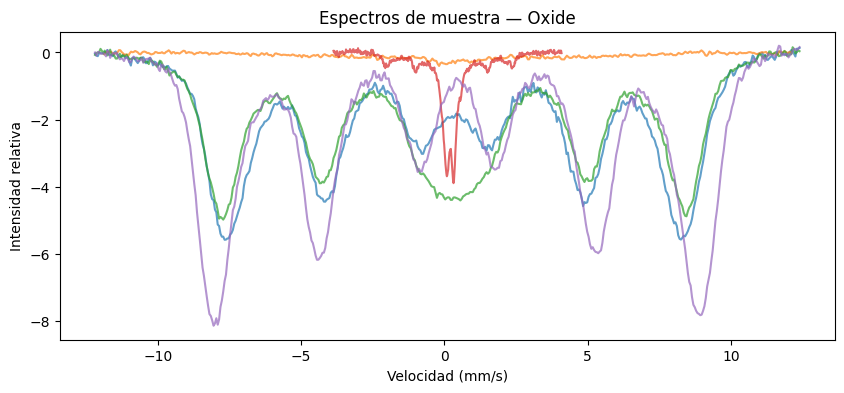

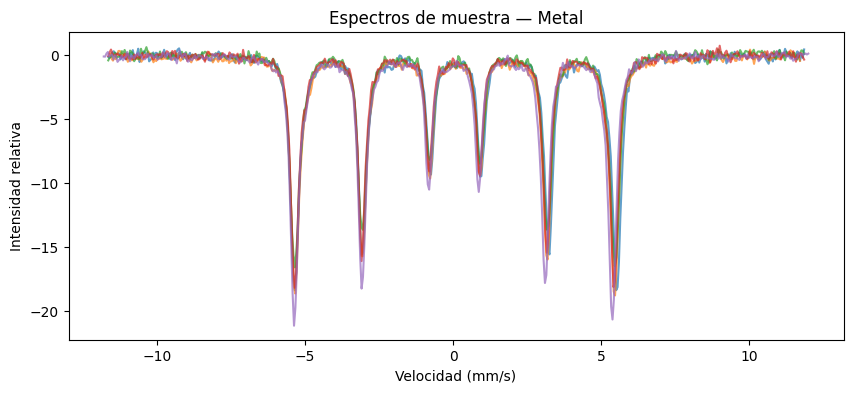

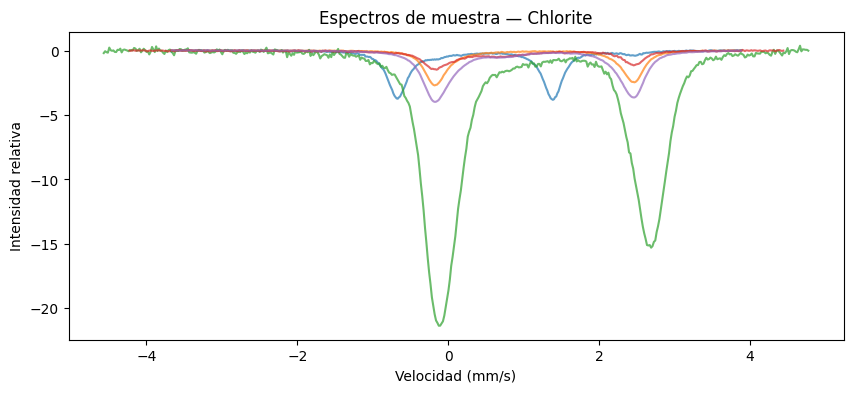

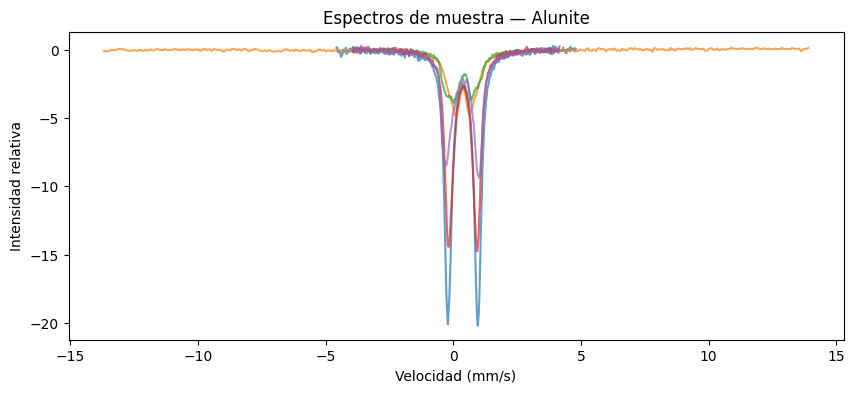

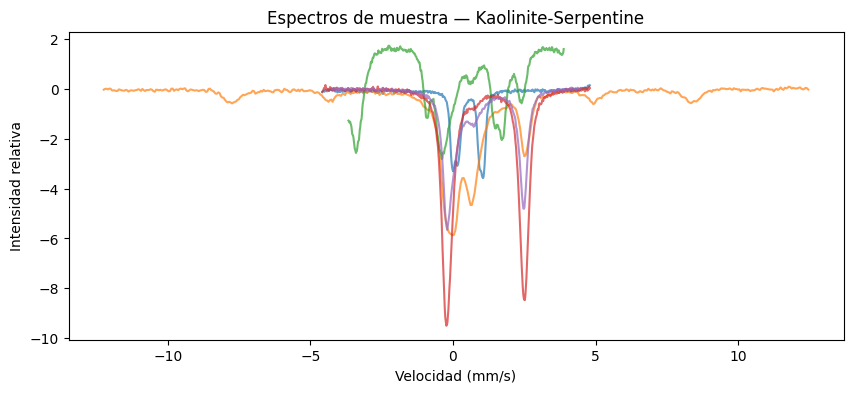

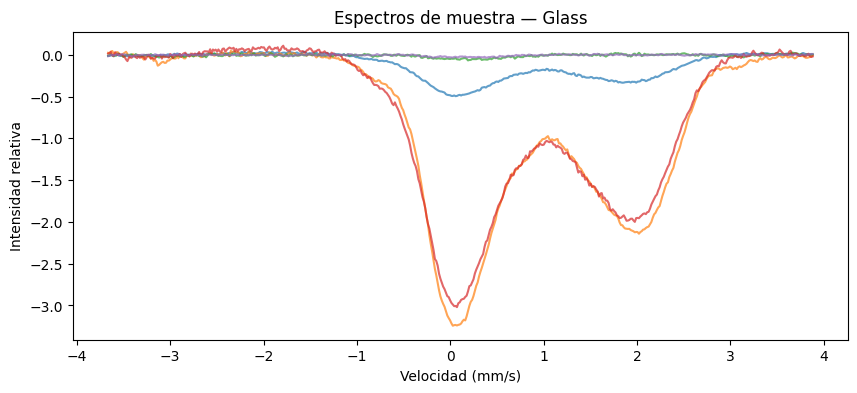

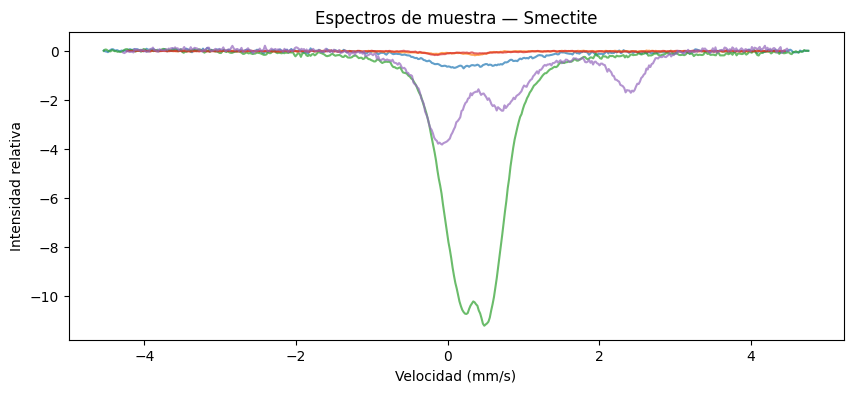

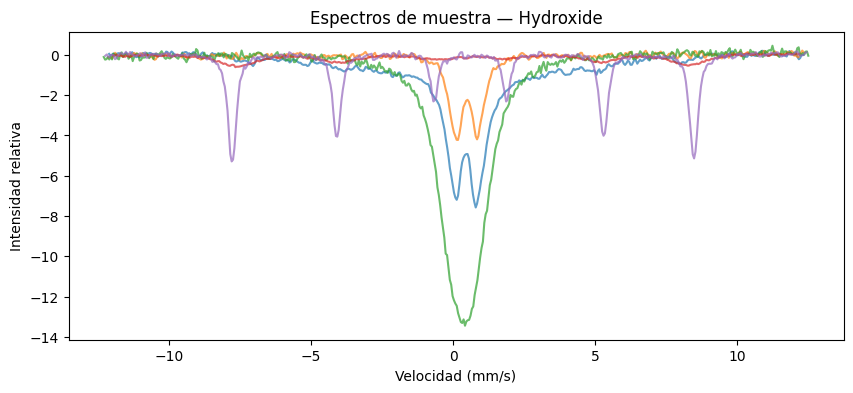

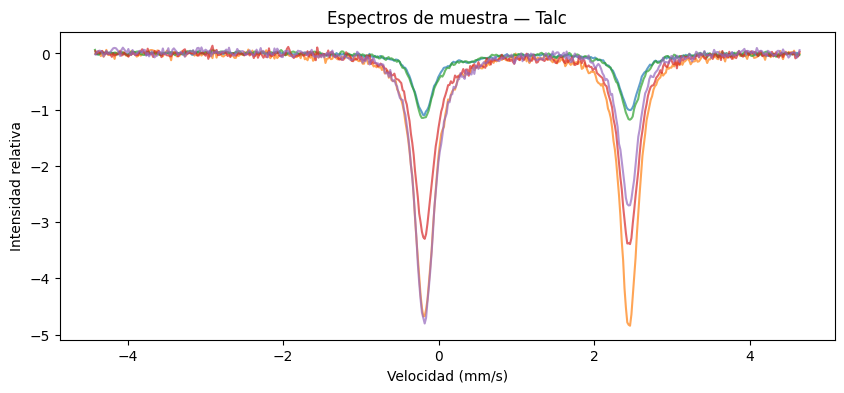

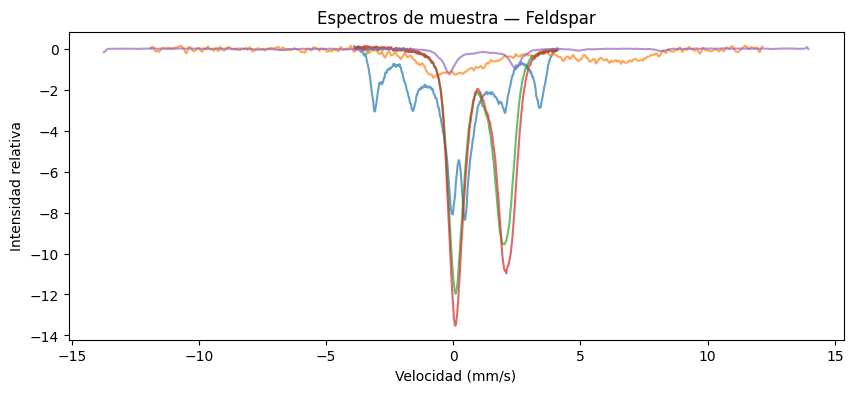

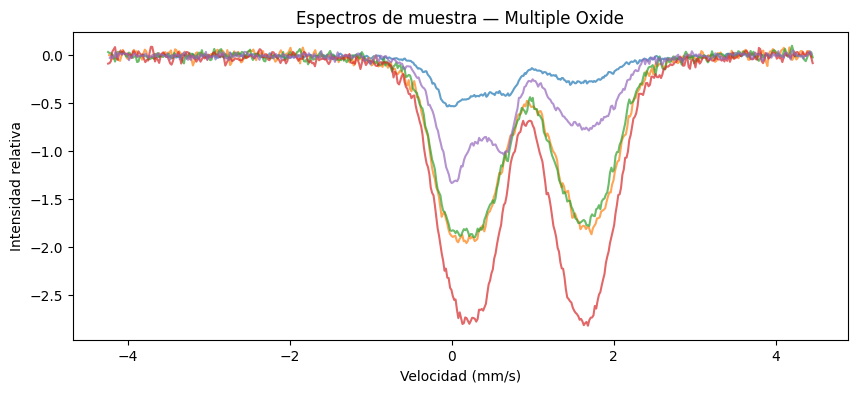

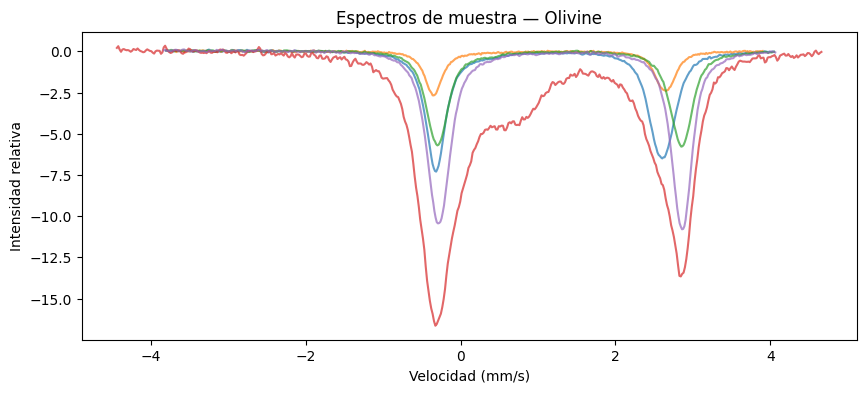

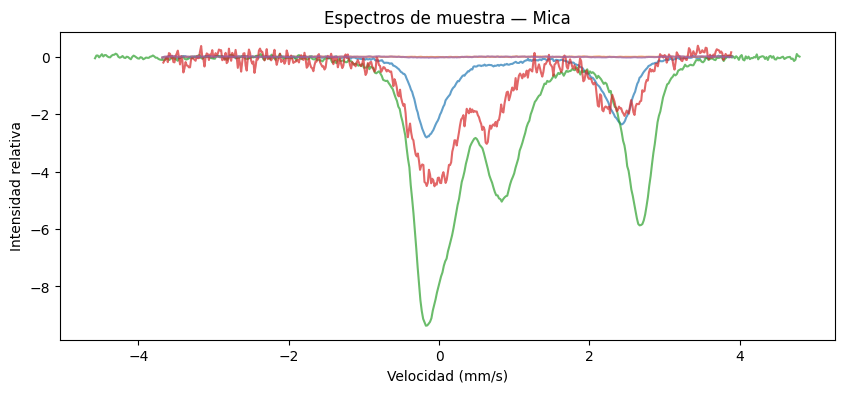

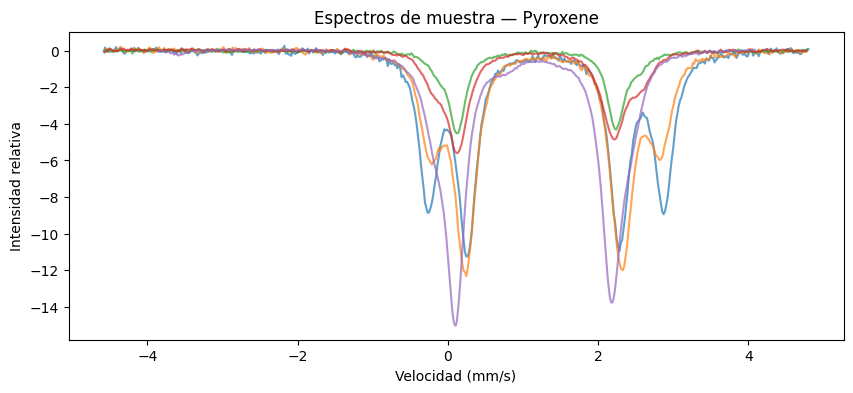

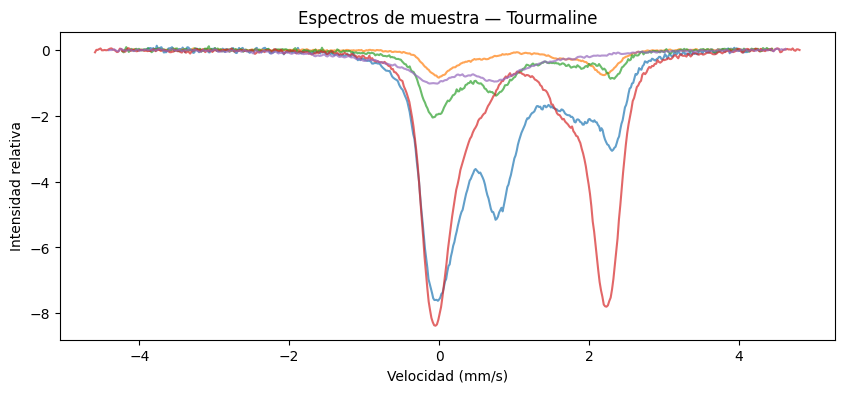

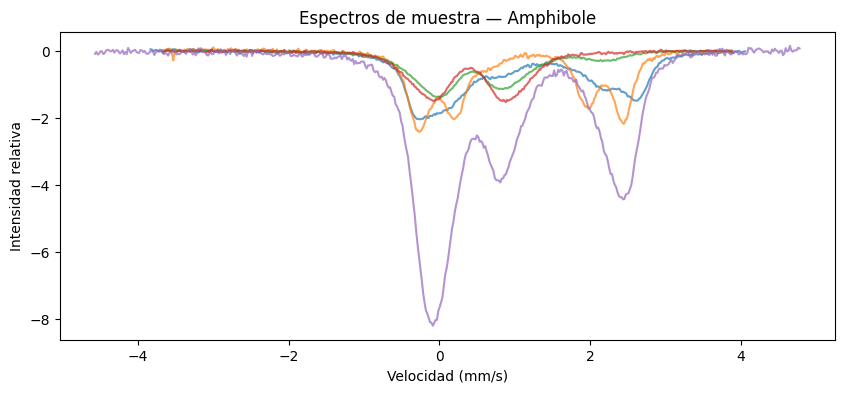

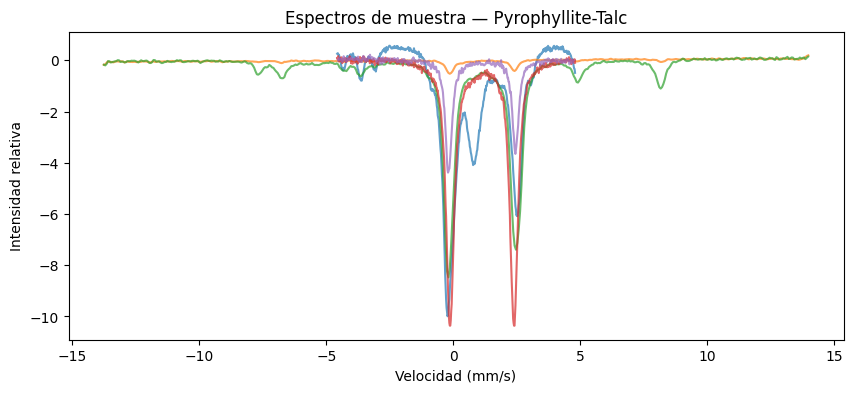

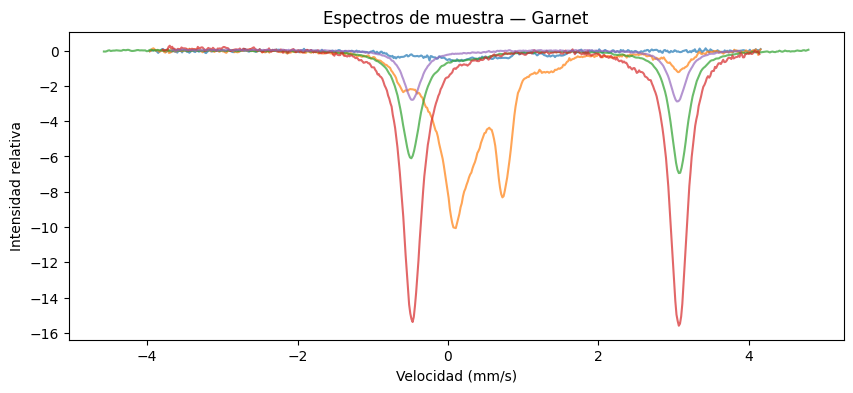

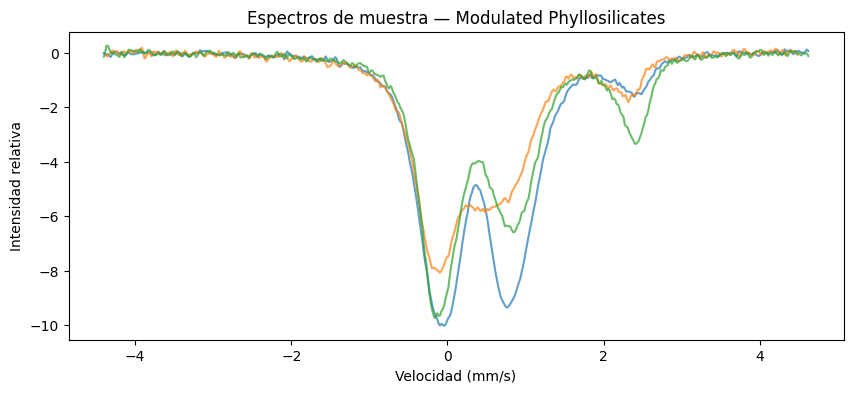

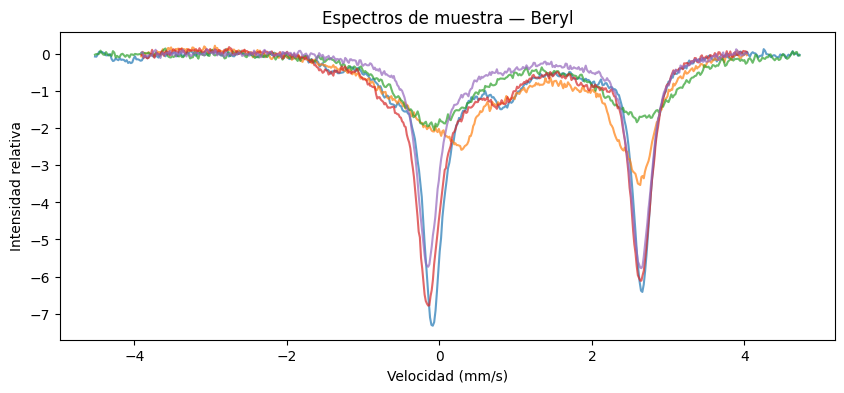

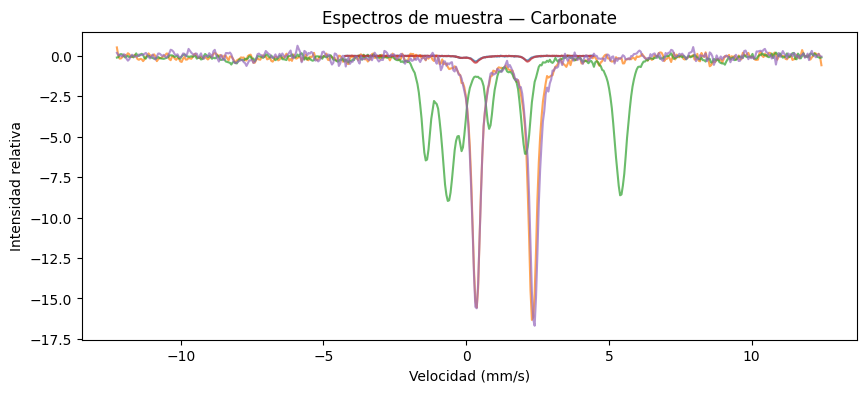

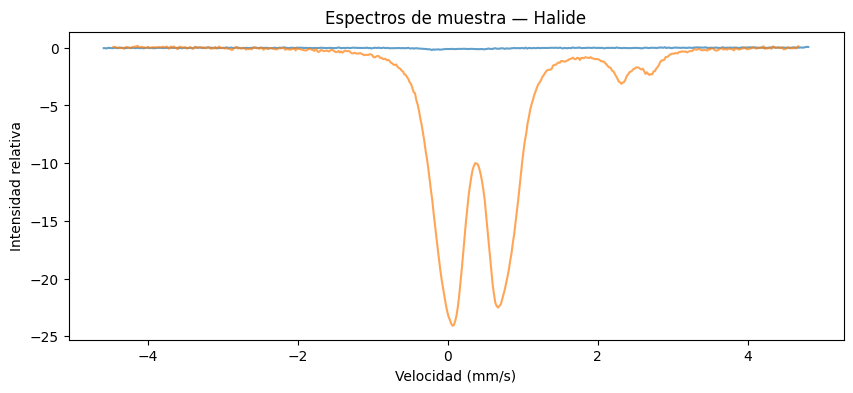

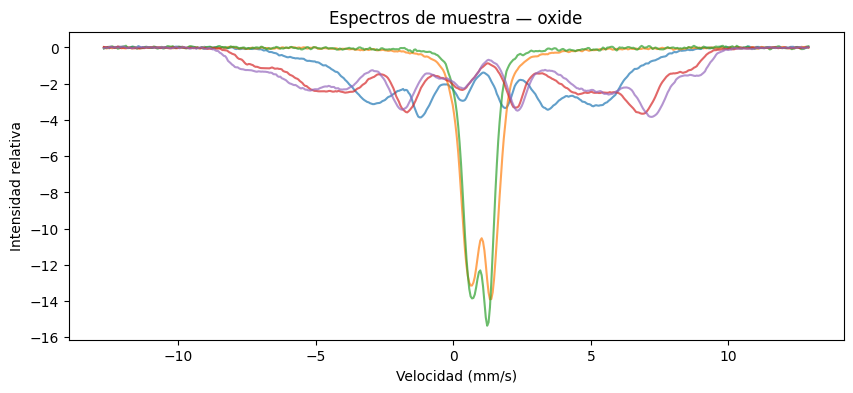

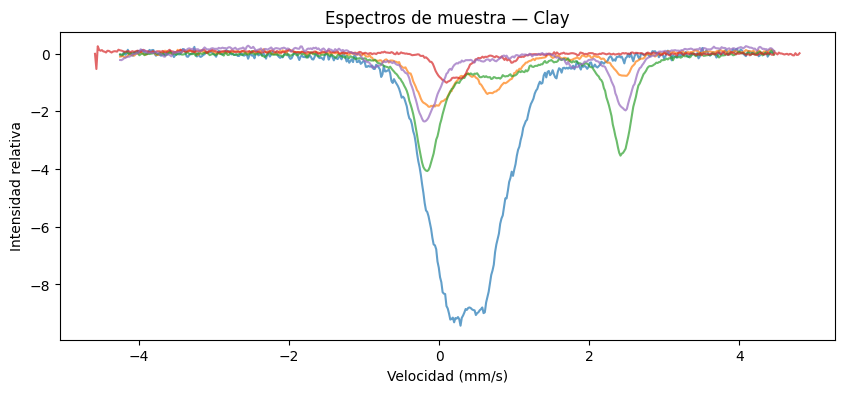

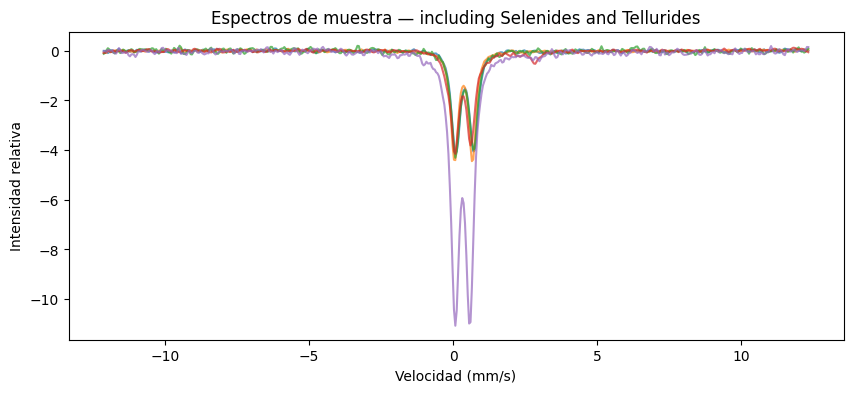

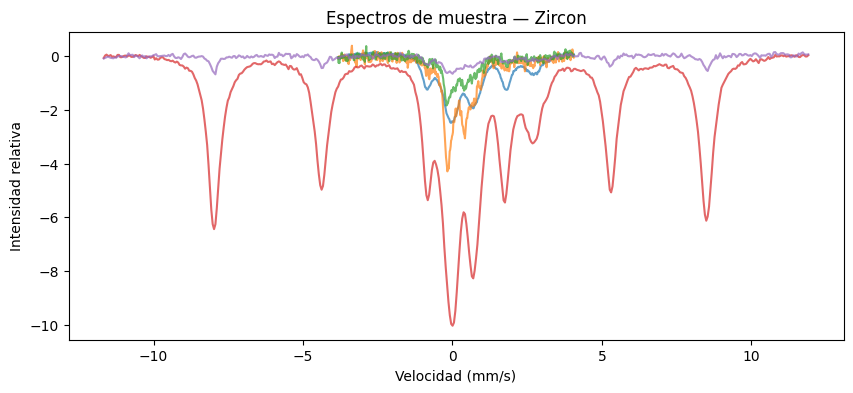

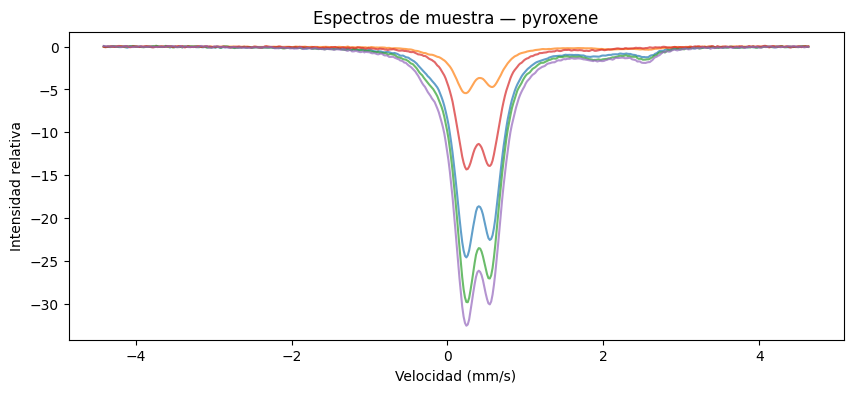

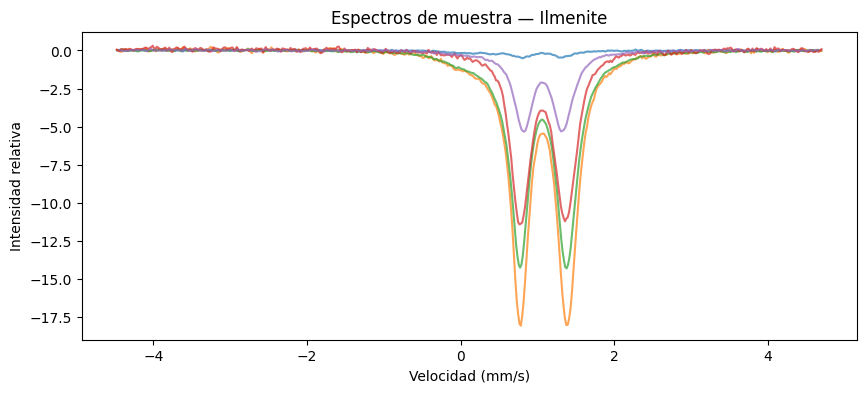

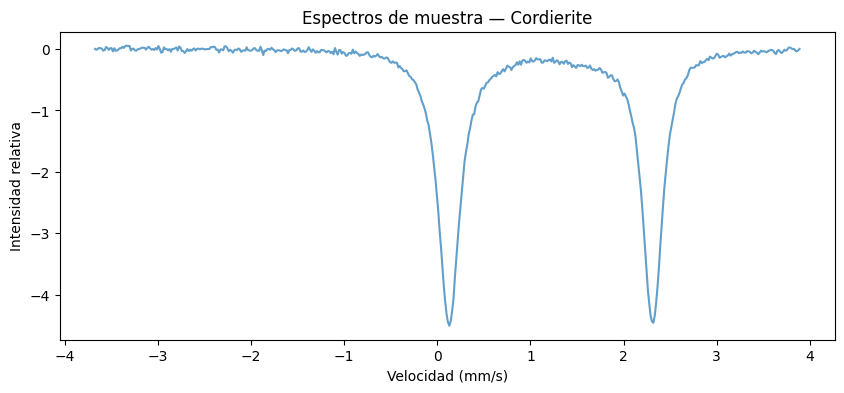

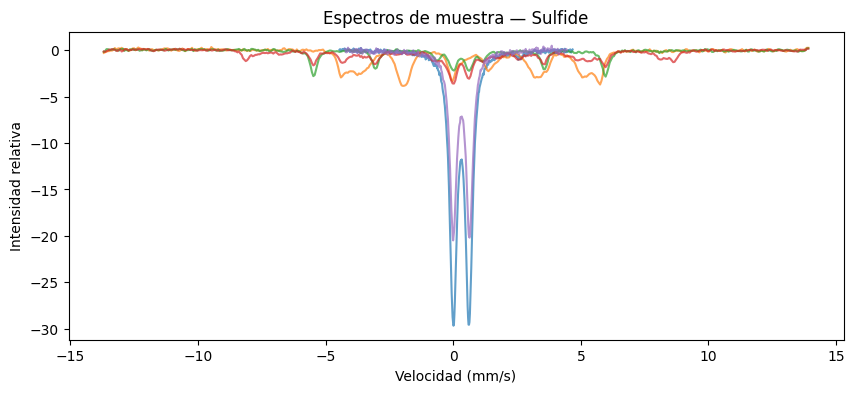

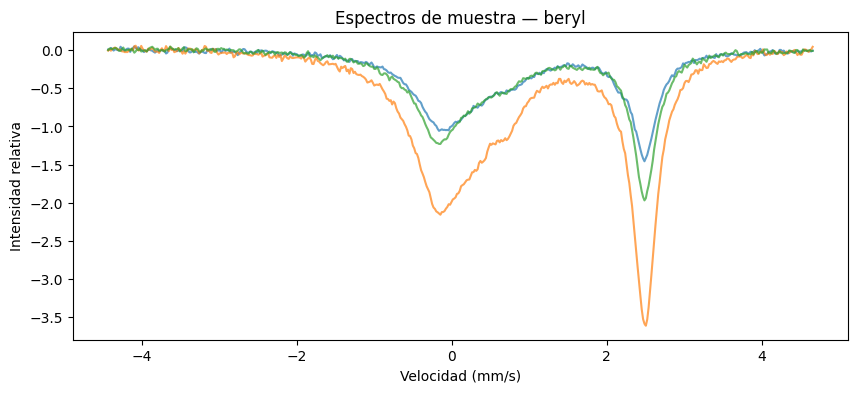

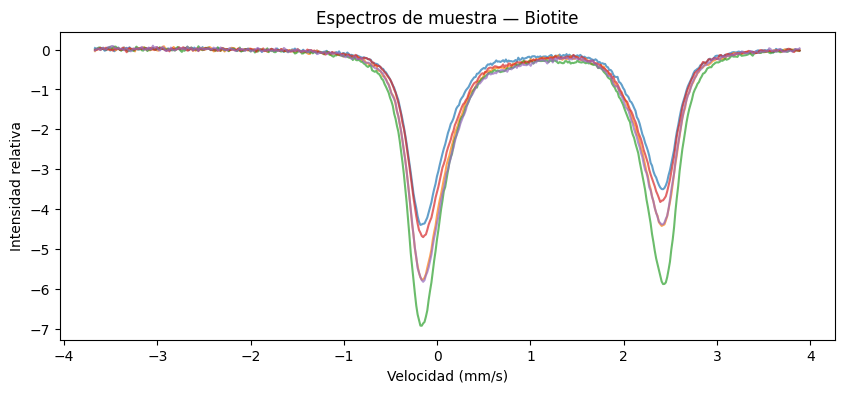

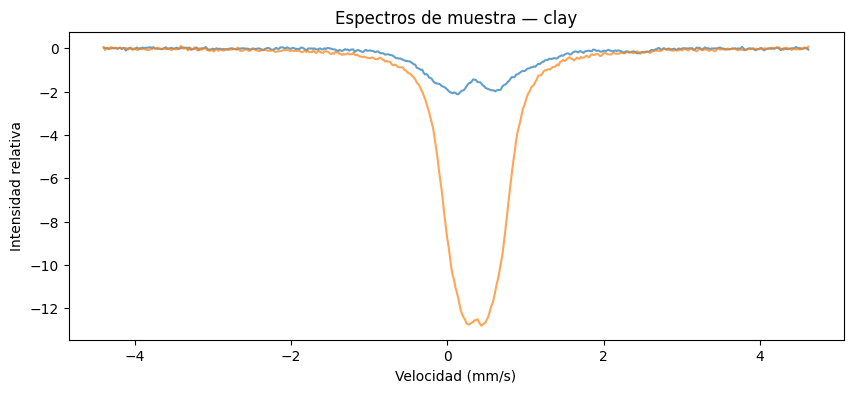

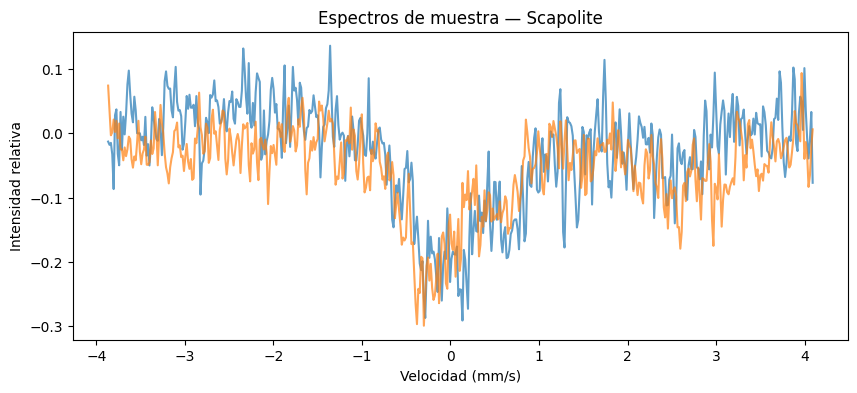

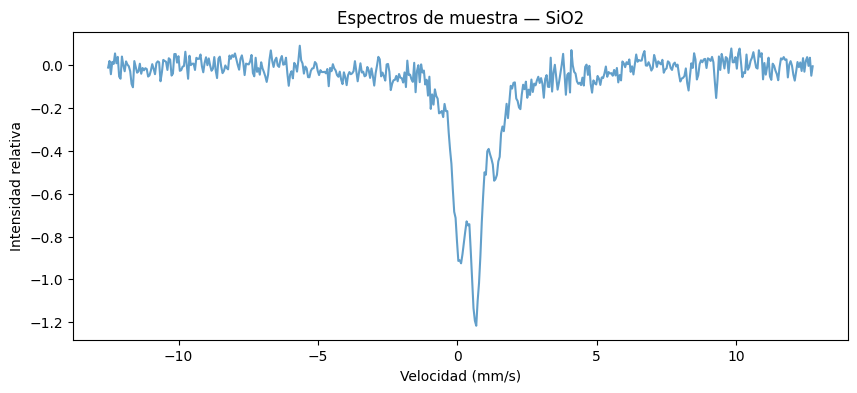

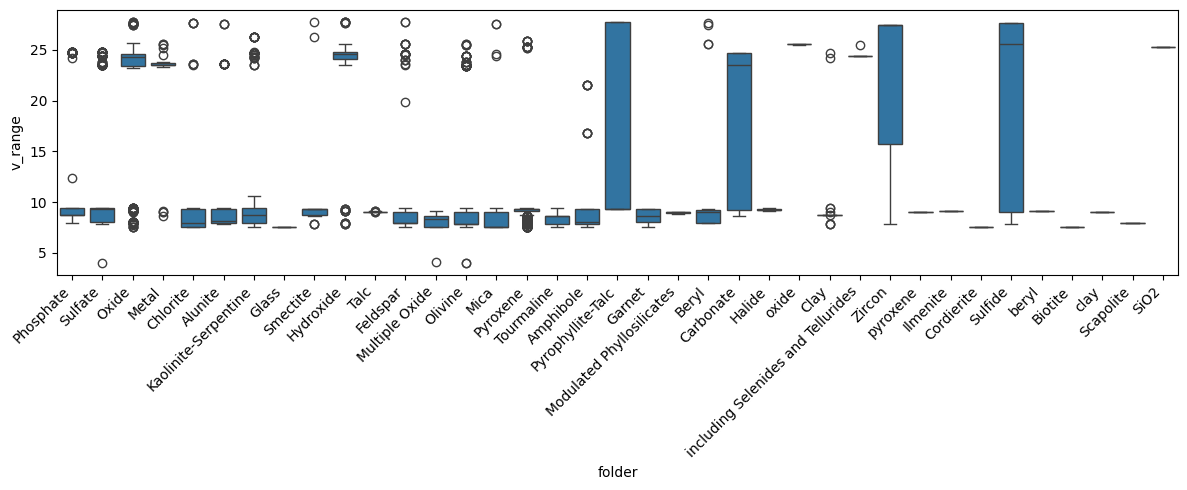

✓ Gráficos EDA generados en outputs/eda/


In [8]:
os.makedirs('outputs/eda', exist_ok=True)

# Plot 1: Distribución de longitudes ANTES de la interpolación
lengths = [len(v) for v in df['velocity_filtered']]
plt.figure()
plt.hist(lengths, bins=40, color='skyblue', edgecolor='black')
plt.title('Distribución de longitudes de espectro (post-filtro, pre-interpolación)')
plt.xlabel('N puntos')
plt.ylabel('Frecuencia')
plt.savefig('outputs/eda/01_longitudes.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Plot 2: Distribución de clases (columna folder)
plt.figure(figsize=(12, 5))
df['folder'].value_counts().plot(kind='bar', color='coral', edgecolor='black')
plt.title('Frecuencia de clases cristaloquímicas (folder)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/eda/02_distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Plot 3: 5 espectros de muestra por clase (post-interpolación)
clases = df['folder'].unique()
for cls in clases:
    subset = df[df['folder'] == cls].head(5)
    plt.figure(figsize=(10, 4))
    for _, row in subset.iterrows():
        plt.plot(row['velocity_uniform'], row['intensity_uniform'], alpha=0.7)
    plt.title(f'Espectros de muestra — {cls}')
    plt.xlabel('Velocidad (mm/s)')
    plt.ylabel('Intensidad relativa')
    safe_cls_name = str(cls).replace('/', '_')
    plt.savefig(f'outputs/eda/03_espectros_{safe_cls_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

# Plot 4: Boxplot de rangos de velocidad por clase
v_ranges = df.apply(
    lambda r: max(r['velocity_filtered']) - min(r['velocity_filtered']), axis=1
)
df['v_range'] = v_ranges
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='folder', y='v_range')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/eda/04_rango_velocidad_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("✓ Gráficos EDA generados en outputs/eda/")

## 1.5 Codificación One-Hot — Mapeo cristaloquímico sobre folder

In [ ]:
FOLDER_TO_CLASS = {
    # Clase 0: Silicatos
    'Chlorite': 0, 'Kaolinite-Serpentine': 0, 'Smectite': 0, 'Talc': 0,
    'Feldspar': 0, 'Olivine': 0, 'Mica': 0, 'Pyroxene': 0, 'pyroxene': 0,
    'Tourmaline': 0, 'Amphibole': 0, 'Pyrophyllite-Talc': 0, 'Garnet': 0,
    'Modulated Phyllosilicates': 0, 'Beryl': 0, 'beryl': 0,
    'Clay': 0, 'clay': 0, 'Zircon': 0, 'Allophane': 0, 'Cordierite': 0,
    'Biotite': 0, 'Scapolite': 0, 'SiO2': 0,
    # Clase 1: Óxidos e Hidróxidos
    'Oxide': 1, 'oxide': 1, 'Multiple Oxide': 1, 'Hydroxide': 1, 'Ilmenite': 1,
    # Clase 2: Sulfatos
    'Sulfate': 2, 'Alunite': 2, 'Jarosite': 2,
    # Clase 3: Sulfuros y Telururos
    'Sulfide': 3, 'including Selenides and Tellurides': 3,
    # Clase 4: Oxisales Complejas
    'Carbonate': 4, 'Phosphate': 4,
    # Clase 5: Haluros
    'Halide': 5,
    # Clase 6: Metales / Elementos Nativos
    'Metal': 6,
    # Clase 7: Materiales Amorfos
    'Glass': 7,
}
NUM_CHEM_CLASSES = 8

df['chem_label'] = df['folder'].map(FOLDER_TO_CLASS)

unmapped = df[df['chem_label'].isna()]['folder'].unique()
if len(unmapped) > 0:
    print(f"⚠️ Valores de 'folder' sin mapeo ({len(unmapped)}): {unmapped}")
    print("   → Estas filas serán eliminadas del dataset final.")
    df = df[df['chem_label'].notna()].reset_index(drop=True)

df['chem_label'] = df['chem_label'].astype(int)

labels_tensor = torch.tensor(df['chem_label'].values, dtype=torch.long)
onehot = F.one_hot(labels_tensor, num_classes=NUM_CHEM_CLASSES).numpy()
df['chem_onehot'] = [row.tolist() for row in onehot]
print("✓ Codificación One-Hot completada.")

✓ Codificación One-Hot completada.


## 1.6 Generación de pseudo-etiquetas topológicas con ajuste paralelo

In [ ]:
print("Iniciando ajuste multiproceso de modelos Mössbauer Lmfit...")

tasks = []
for idx, row in df.iterrows():
    tasks.append((idx, row['pkey'], row['velocity_uniform'], row['intensity_uniform']))

num_workers = max(1, int(cpu_count() * 0.8))
print(f"Ejecutando con {num_workers} procesos en paralelo...")

topo_labels = [0] * len(df)
p_vecs = [[]] * len(df)
bic_winners = [0] * len(df)
rmse_scores = [0.0] * len(df)

with Pool(processes=num_workers) as pool:
    for result in tqdm(pool.imap(fit_worker, tasks), total=len(tasks)):
        idx, topo_lbl, p_vec, bic_w, rmse = result
        topo_labels[idx] = topo_lbl
        p_vecs[idx] = p_vec
        bic_winners[idx] = bic_w
        rmse_scores[idx] = rmse

df['topo_label'] = topo_labels
df['P_vec'] = p_vecs
df['bic_winner'] = bic_winners
df['fit_residual_rmse'] = rmse_scores

os.makedirs('outputs', exist_ok=True)
df.to_parquet('outputs/mossbauer_processed.parquet', index=False)
print("✓ Dataset procesado guardado en outputs/mossbauer_processed.parquet")
print(f"  Shape final: {df.shape}")
print(f"  Distribución de clases químicas:\n{df['chem_label'].value_counts().to_string()}")
print(f"  Distribución de clases topológicas:\n{df['topo_label'].value_counts().to_string()}")

Iniciando ajuste multiproceso de modelos Mössbauer Lmfit...
Ejecutando con 9 procesos en paralelo...


100%|██████████| 1361/1361 [00:14<00:00, 96.97it/s] 


✓ Dataset procesado guardado en outputs/mossbauer_processed.parquet
  Shape final: (1361, 19)
  Distribución de clases químicas:
chem_label
1    788
0    291
2    143
6     63
4     45
3     31
  Distribución de clases topológicas:
topo_label
0    1328
1      20
2      10
4       3
